# 📊 HR Analytics Deep-Dive: Employee Lifecycle, Attrition Risk, Exit Sentiment, Pay Parity & Compliance

**Dataset**: Synthetic HR Analytics Company (1,500 Employees, India)  
**Snapshot Date**: 30-Sep-2026  
**Primary Key**: `employee_id`

---

## 📌 Executive Summary & Notebook Scope
This notebook delivers a comprehensive, end-to-end data science analysis across all 10 modular HR datasets. It addresses four key operational and strategic dimensions:

1. **Attrition Drivers & Early Warning Indicators**: Baseline exit metrics, multi-variable risk factor breakdown, pre-exit attendance behavior patterns, and a Machine Learning predictive model (Random Forest / Logistic Regression) to identify flight-risk employees.
2. **Qualitative Exit Review NLP Sentiment & Text Mining**: Automated VADER sentiment scoring on 185 raw text exit reviews, correlation with quantitative ratings, detection of mixed-sentiment feedback, and driver identification.
3. **Recruitment & Workforce Efficiency**: Hiring funnel metrics (Time-to-Hire, Cost-per-Hire by source), recruitment source quality vs. early attrition, headcount vs. target gaps, span of control, and gender pay gap analysis.
4. **HR Compliance, Legal & Risk Auditing**: Mandatory training completion rates (POSH, DPDP, InfoSec, CoC), background verification (BGV) clearance, NDA coverage, and legal grievance/POSH complaint tracking.

---


In [1]:
# Imports & Configuration
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import LabelEncoder

import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Modern Matplotlib & Seaborn Formatting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
sns.set_palette('deep')

print("✅ Environment initialized successfully.")


✅ Environment initialized successfully.


In [2]:
# Load all 10 CSV datasets
data_dir = 'datasets'

departments_df = pd.read_csv(os.path.join(data_dir, '01_departments.csv'))
employees_df = pd.read_csv(os.path.join(data_dir, '02_employees.csv'))
attrition_df = pd.read_csv(os.path.join(data_dir, '03_attrition_exits.csv'))
exit_reviews_df = pd.read_csv(os.path.join(data_dir, '04_exit_reviews_raw.csv'))
performance_df = pd.read_csv(os.path.join(data_dir, '05_performance.csv'))
engagement_df = pd.read_csv(os.path.join(data_dir, '06_engagement_survey.csv'))
compliance_trng_df = pd.read_csv(os.path.join(data_dir, '07_compliance_trainings.csv'))
compliance_rec_df = pd.read_csv(os.path.join(data_dir, '08_compliance_employee_records.csv'))
attendance_df = pd.read_csv(os.path.join(data_dir, '09_attendance_leave.csv'))
recruitment_df = pd.read_csv(os.path.join(data_dir, '10_recruitment.csv'))

# Create Master Employee Dataframe
master_df = employees_df.merge(attrition_df, on='employee_id', how='left')
master_df = master_df.merge(compliance_rec_df, on='employee_id', how='left')
master_df = master_df.merge(departments_df[['dept_id', 'dept_name', 'hq_location']], on='dept_id', how='left', suffixes=('', '_dept'))

# Define target variable for Attrition
master_df['is_attrite'] = (master_df['employment_status'] == 'Exited').astype(int)

print(f"📁 Master Employee Dataset Assembled: {master_df.shape[0]} rows, {master_df.shape[1]} columns")
print(f"Total Active Headcount: {(master_df['is_attrite'] == 0).sum()} | Total Exits: {(master_df['is_attrite'] == 1).sum()}")


📁 Master Employee Dataset Assembled: 1500 rows, 45 columns
Total Active Headcount: 1237 | Total Exits: 263


---
## 🔍 Section 1: Attrition Drivers & Early Warning Indicators

In this section, we analyze attrition metrics across dimensions, identify critical risk factors (Overtime, L1 Level, Sales/Support, Commute, Age < 28), track pre-exit attendance behavior patterns, and build a Machine Learning predictive risk model.


             KEY ATTRITION METRICS                
Total Company Headcount : 1,500
Total Exits              : 263 (Rate: 17.53%)
  • Voluntary Exits      : 215 (81.7%)
  • Involuntary Exits    : 48 (18.3%)
Regrettable Attrition    : 88 (33.5% of total exits)
Early Attrition (< 6 mo) : 74 (28.1% of exits)
Early Attrition (<12 mo) : 119 (45.2% of exits)
Average Tenure at Exit   : 26.4 months


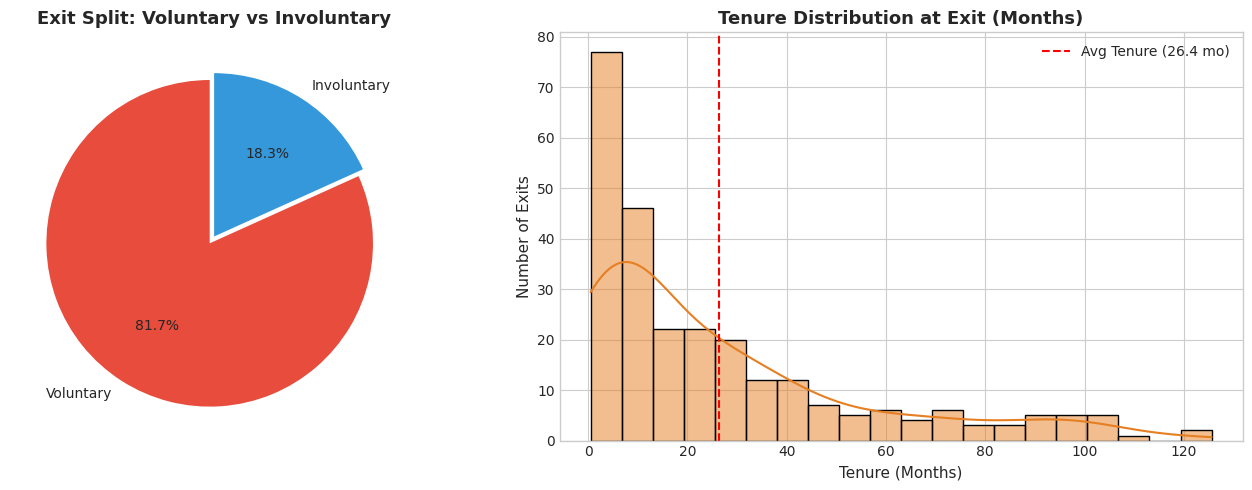

In [3]:
# 1.1 Core Attrition Metrics Calculation
total_headcount = len(employees_df)
total_exits = len(attrition_df)
overall_attrition_rate = (total_exits / total_headcount) * 100

voluntary_exits = (attrition_df['exit_type'] == 'Voluntary').sum()
involuntary_exits = (attrition_df['exit_type'] == 'Involuntary').sum()
regrettable_exits = (attrition_df['regrettable_loss'] == 'Yes').sum()
regrettable_pct = (regrettable_exits / total_exits) * 100

early_exits_6m = (attrition_df['tenure_months'] < 6).sum()
early_exits_12m = (attrition_df['tenure_months'] < 12).sum()
early_attrition_6m_rate = (early_exits_6m / total_exits) * 100
early_attrition_12m_rate = (early_exits_12m / total_exits) * 100
avg_tenure_exit = attrition_df['tenure_months'].mean()

print("==================================================")
print("             KEY ATTRITION METRICS                ")
print("==================================================")
print(f"Total Company Headcount : {total_headcount:,}")
print(f"Total Exits              : {total_exits} (Rate: {overall_attrition_rate:.2f}%)")
print(f"  • Voluntary Exits      : {voluntary_exits} ({voluntary_exits/total_exits*100:.1f}%)")
print(f"  • Involuntary Exits    : {involuntary_exits} ({involuntary_exits/total_exits*100:.1f}%)")
print(f"Regrettable Attrition    : {regrettable_exits} ({regrettable_pct:.1f}% of total exits)")
print(f"Early Attrition (< 6 mo) : {early_exits_6m} ({early_attrition_6m_rate:.1f}% of exits)")
print(f"Early Attrition (<12 mo) : {early_exits_12m} ({early_attrition_12m_rate:.1f}% of exits)")
print(f"Average Tenure at Exit   : {avg_tenure_exit:.1f} months")
print("==================================================")

# Visualization 1.1: Attrition Overview & Tenure Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Exit Types
exit_type_counts = attrition_df['exit_type'].value_counts()
colors = ['#e74c3c', '#3498db']
axes[0].pie(exit_type_counts, labels=exit_type_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0))
axes[0].set_title('Exit Split: Voluntary vs Involuntary')

# Plot 2: Tenure at Exit
sns.histplot(attrition_df['tenure_months'], bins=20, kde=True, ax=axes[1], color='#e67e22')
axes[1].axvline(avg_tenure_exit, color='red', linestyle='--', label=f'Avg Tenure ({avg_tenure_exit:.1f} mo)')
axes[1].set_title('Tenure Distribution at Exit (Months)')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Number of Exits')
axes[1].legend()

plt.tight_layout()
plt.show()


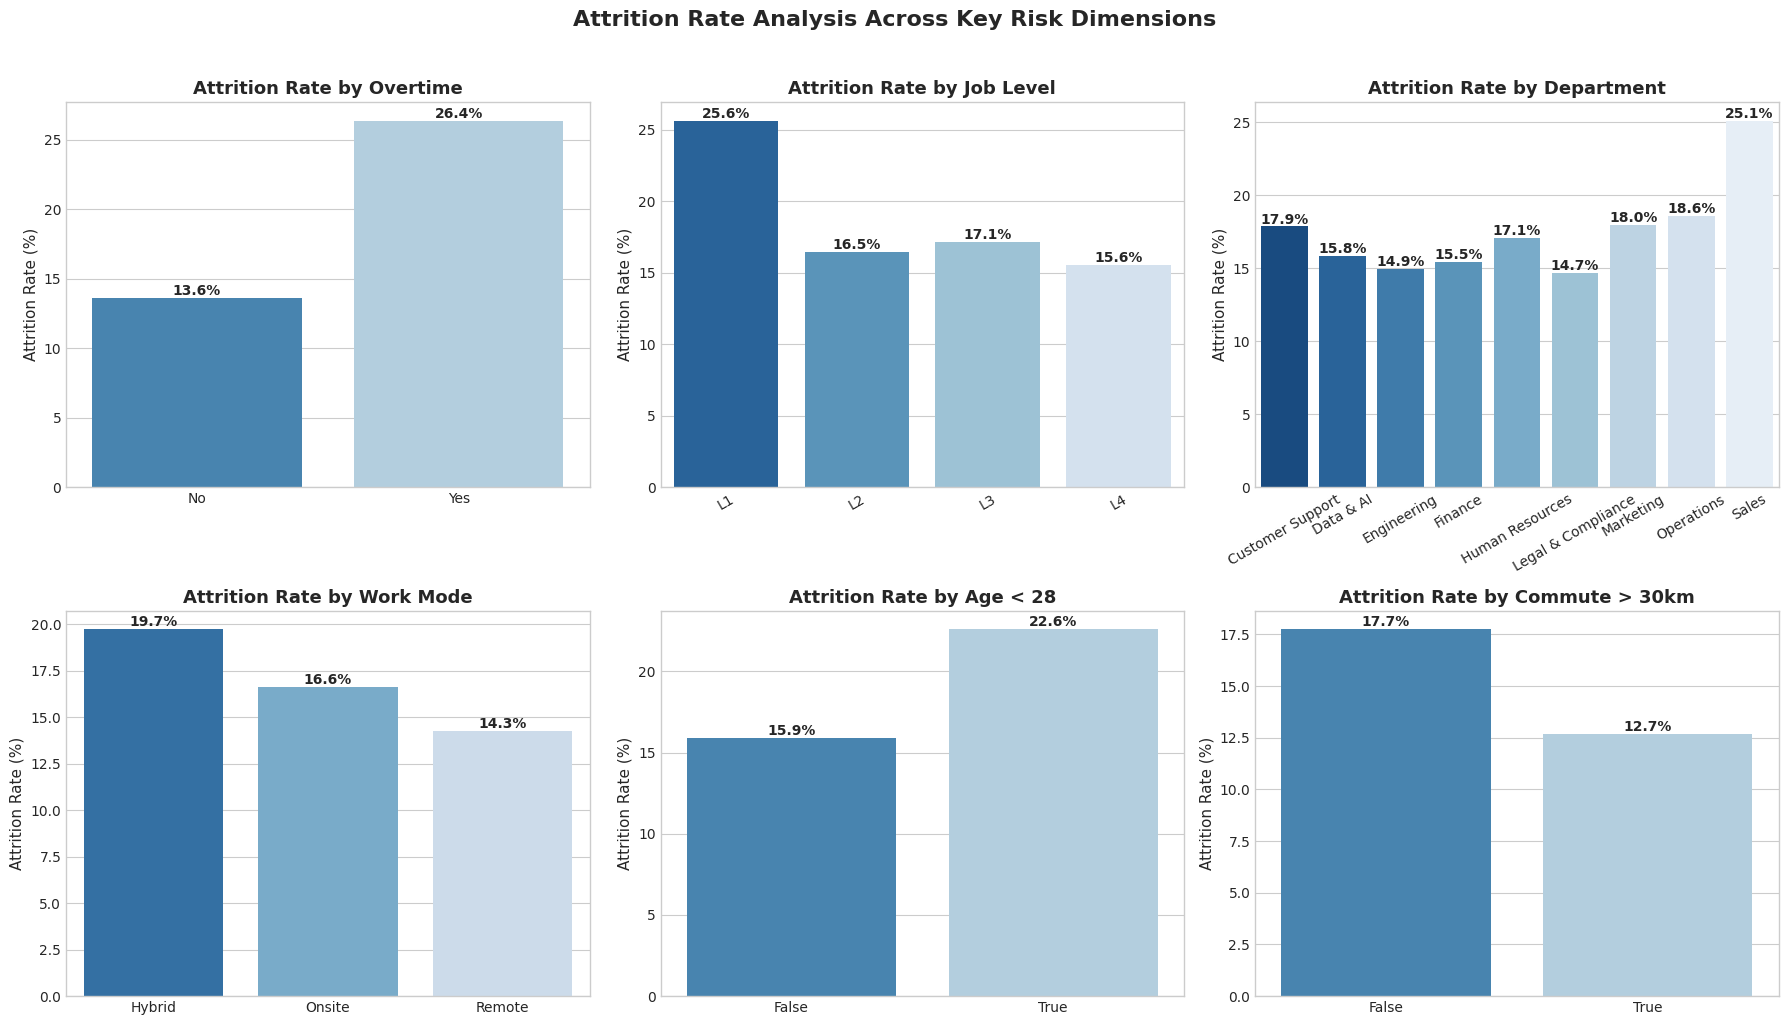

In [4]:
# 1.2 High Exit Risk Factor Breakdown
master_df['is_age_under_28'] = master_df['age'] < 28
master_df['is_long_commute'] = master_df['distance_from_home_km'] > 30

risk_factors = {
    'Overtime': 'overtime',
    'Job Level': 'job_level',
    'Department': 'department',
    'Work Mode': 'work_mode',
    'Age < 28': 'is_age_under_28',
    'Commute > 30km': 'is_long_commute'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (label, col) in enumerate(risk_factors.items()):
    attr_rate = master_df.groupby(col)['is_attrite'].mean() * 100
    ax = axes[idx]
    sns.barplot(x=attr_rate.index, y=attr_rate.values, ax=ax, palette='Blues_r')
    ax.set_title(f'Attrition Rate by {label}')
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_xlabel('')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
    if col in ['department', 'job_level']:
        ax.tick_params(axis='x', rotation=30)

plt.suptitle('Attrition Rate Analysis Across Key Risk Dimensions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


📊 Attendance & Behavioral Differences (Monthly Averages per Employee):
              Group  unplanned_absence  late_logins  overtime_hours
0  Active Employees           0.300090     1.495508        4.224319
1  Exited Employees           0.930841     1.485981        6.590654


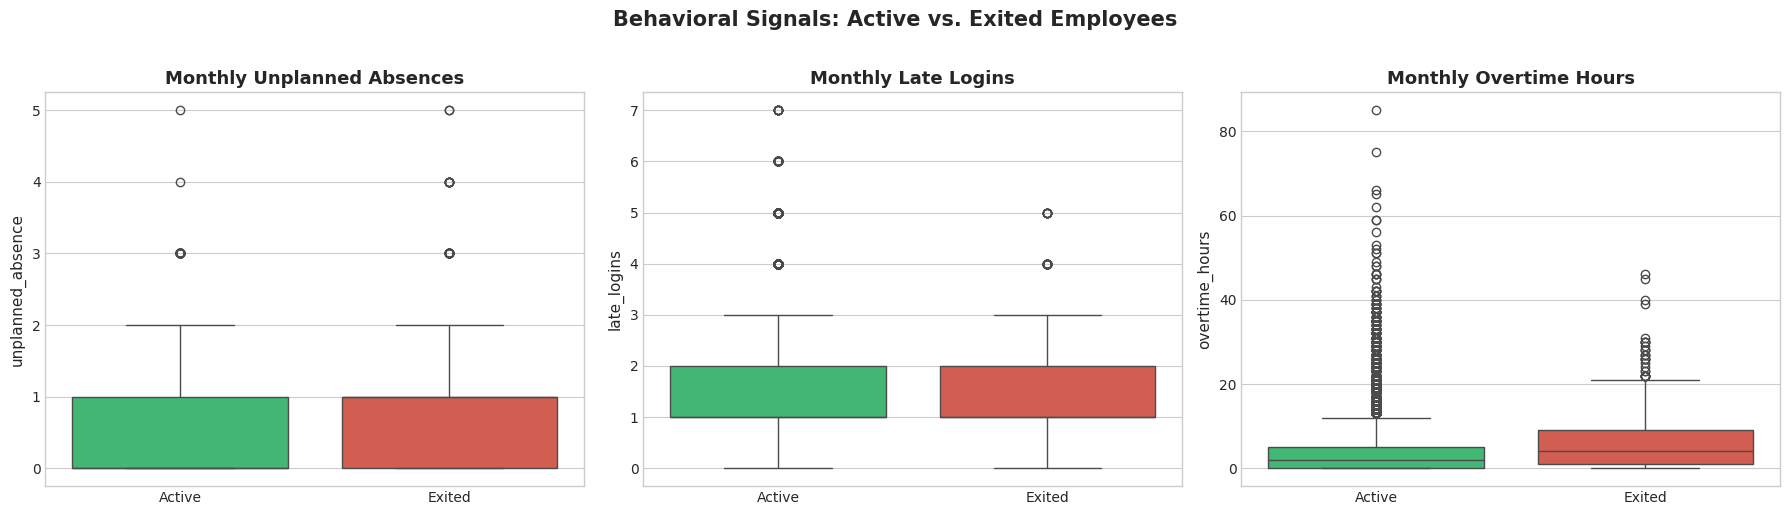

In [5]:
# 1.3 Behavioral Early Warning Signals from Attendance & Leave Data
exited_ids = set(attrition_df['employee_id'])
active_ids = set(employees_df[employees_df['employment_status'] == 'Active']['employee_id'])

# Compute average monthly metrics for Active vs Exited employees
attendance_df['is_exited'] = attendance_df['employee_id'].isin(exited_ids)

attend_summary = attendance_df.groupby('is_exited')[['unplanned_absence', 'late_logins', 'overtime_hours']].mean().reset_index()
attend_summary['Group'] = attend_summary['is_exited'].map({False: 'Active Employees', True: 'Exited Employees'})

print("📊 Attendance & Behavioral Differences (Monthly Averages per Employee):")
print(attend_summary[['Group', 'unplanned_absence', 'late_logins', 'overtime_hours']])

# Monthly trend plot for Exited vs Active
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=attendance_df, x='is_exited', y='unplanned_absence', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_xticklabels(['Active', 'Exited'])
axes[0].set_title('Monthly Unplanned Absences')
axes[0].set_xlabel('')

sns.boxplot(data=attendance_df, x='is_exited', y='late_logins', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_xticklabels(['Active', 'Exited'])
axes[1].set_title('Monthly Late Logins')
axes[1].set_xlabel('')

sns.boxplot(data=attendance_df, x='is_exited', y='overtime_hours', ax=axes[2], palette=['#2ecc71', '#e74c3c'])
axes[2].set_xticklabels(['Active', 'Exited'])
axes[2].set_title('Monthly Overtime Hours')
axes[2].set_xlabel('')

plt.suptitle('Behavioral Signals: Active vs. Exited Employees', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


🤖 Random Forest Model ROC-AUC Score: 0.9681

Classification Report:
              precision    recall  f1-score   support

      Active       0.94      0.99      0.97       309
      Exited       0.94      0.73      0.82        66

    accuracy                           0.94       375
   macro avg       0.94      0.86      0.89       375
weighted avg       0.94      0.94      0.94       375



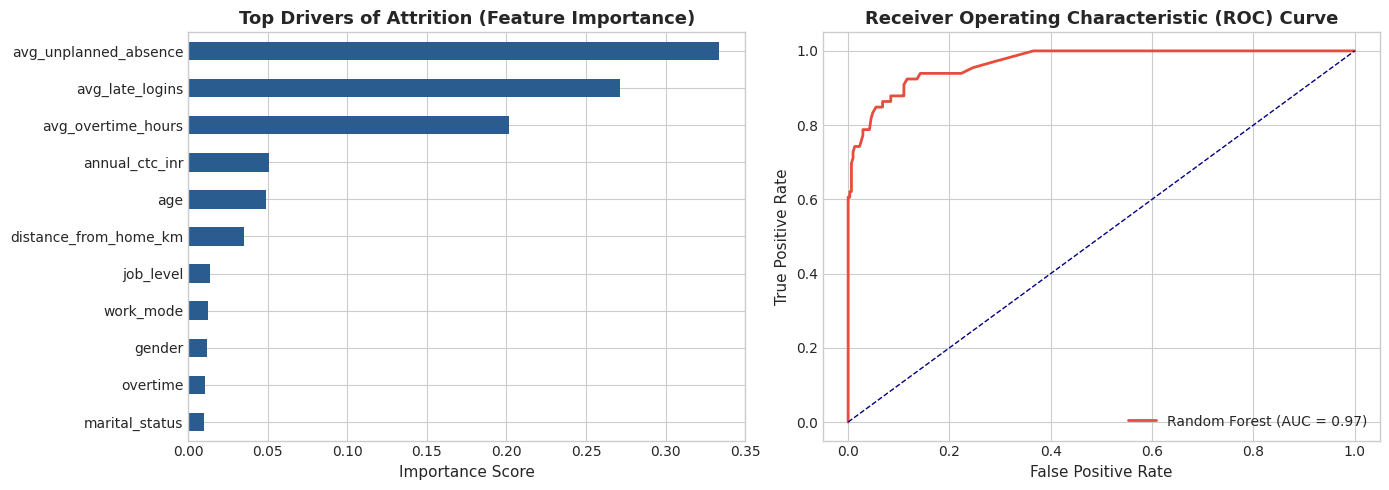

In [6]:
# 1.4 Predictive ML Model for Attrition Risk

# Feature Engineering from Attendance
agg_attend = attendance_df.groupby('employee_id').agg(
    avg_unplanned_absence=('unplanned_absence', 'mean'),
    avg_late_logins=('late_logins', 'mean'),
    avg_overtime_hours=('overtime_hours', 'mean')
).reset_index()

# Merge with Master DF
ml_df = master_df.merge(agg_attend, on='employee_id', how='left').fillna(0)

# Select Predictors
feature_cols = [
    'age', 'annual_ctc_inr', 'distance_from_home_km', 'overtime',
    'work_mode', 'job_level', 'gender', 'marital_status',
    'avg_unplanned_absence', 'avg_late_logins', 'avg_overtime_hours'
]

X = ml_df[feature_cols].copy()
y = ml_df['is_attrite']

# Encode Categoricals
le_dict = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_proba)
print(f"🤖 Random Forest Model ROC-AUC Score: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Active', 'Exited']))

# Plot Feature Importances & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature Importance Plot
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[0], color='#2b5c8f')
axes[0].set_title('Top Drivers of Attrition (Feature Importance)')
axes[0].set_xlabel('Importance Score')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Random Forest (AUC = {auc_score:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 💬 Section 2: Qualitative Exit Review NLP Sentiment Analysis

In this section, we process the 185 raw text reviews from `04_exit_reviews_raw.csv` using NLTK's VADER sentiment analyzer, correlate scores with quantitative ratings, and isolate mixed-sentiment feedback.


In [7]:
# 2.1 VADER Sentiment Analysis on Exit Reviews
sia = SentimentIntensityAnalyzer()

reviews_df = exit_reviews_df.copy()

# Compute sentiment scores
reviews_df['sentiment_scores'] = reviews_df['review_text'].apply(lambda x: sia.polarity_scores(str(x)))
reviews_df['compound'] = reviews_df['sentiment_scores'].apply(lambda x: x['compound'])
reviews_df['pos'] = reviews_df['sentiment_scores'].apply(lambda x: x['pos'])
reviews_df['neu'] = reviews_df['sentiment_scores'].apply(lambda x: x['neu'])
reviews_df['neg'] = reviews_df['sentiment_scores'].apply(lambda x: x['neg'])

# Categorize Sentiment Label
def get_sentiment_category(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df['sentiment_category'] = reviews_df['compound'].apply(get_sentiment_category)

print("📝 Exit Review Sentiment Distribution:")
print(reviews_df['sentiment_category'].value_counts())
print("\nSample Reviews & VADER Sentiment:")
print(reviews_df[['stated_reason', 'compound', 'sentiment_category', 'review_text']].head(5))


📝 Exit Review Sentiment Distribution:
sentiment_category
Positive    131
Negative     48
Neutral       6
Name: count, dtype: int64

Sample Reviews & VADER Sentiment:
         stated_reason  compound sentiment_category  \
0    Work-Life Balance    0.3818           Positive   
1       Higher Studies    0.5994           Positive   
2  Better Compensation    0.5574           Positive   
3    Work-Life Balance    0.6428           Positive   
4  Better Compensation    0.6369           Positive   

                                         review_text  
0  Hybrid policy was withdrawn suddenly. Commute ...  
1  Leaving to pursue a Master's degree abroad. Th...  
2  Leaving mainly for money. Nothing against the ...  
3  Late-night calls with clients every day. The w...  
4  I got an offer with a 30% hike. The work here ...  


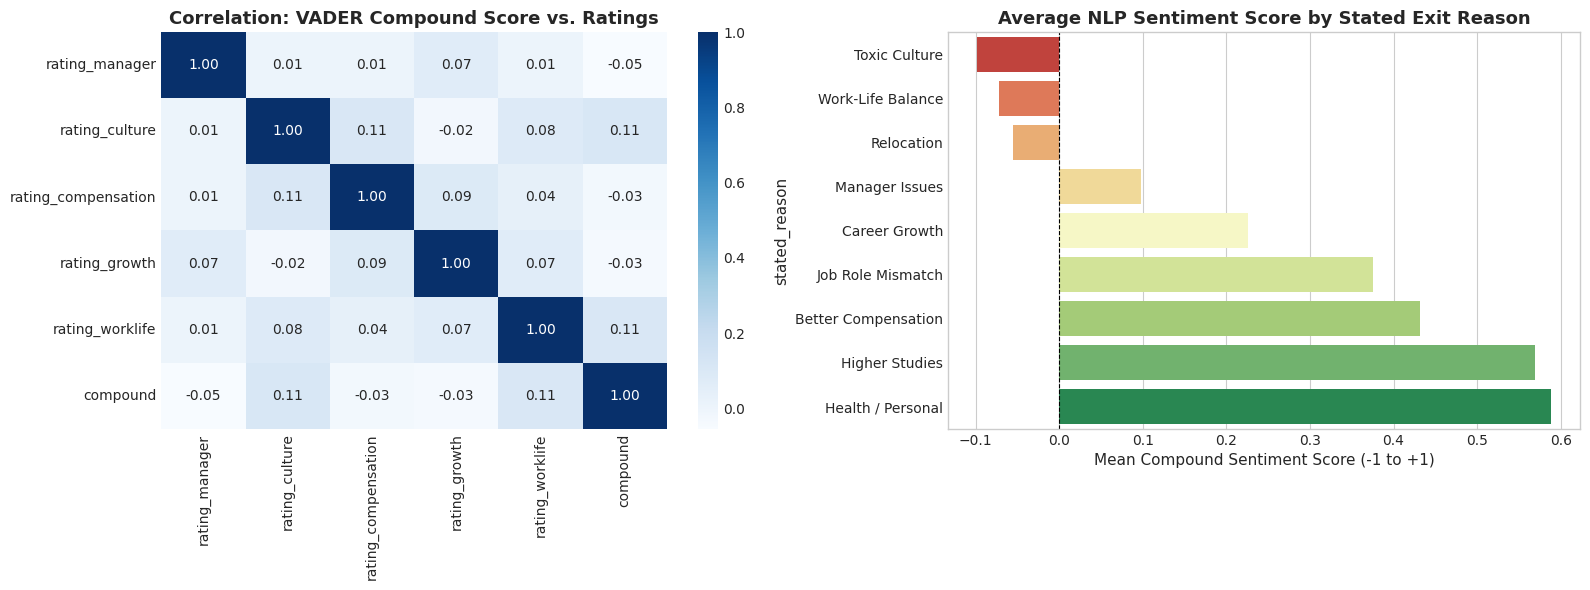

In [8]:
# 2.2 Sentiment Score vs. Quantitative Ratings & Exit Reasons
rating_cols = ['rating_manager', 'rating_culture', 'rating_compensation', 'rating_growth', 'rating_worklife']
corr_matrix = reviews_df[rating_cols + ['compound']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: Sentiment vs Ratings
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', ax=axes[0])
axes[0].set_title('Correlation: VADER Compound Score vs. Ratings')

# Bar Plot: Sentiment by Stated Reason
reason_sentiment = reviews_df.groupby('stated_reason')['compound'].mean().sort_values()
sns.barplot(x=reason_sentiment.values, y=reason_sentiment.index, ax=axes[1], palette='RdYlGn')
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Average NLP Sentiment Score by Stated Exit Reason')
axes[1].set_xlabel('Mean Compound Sentiment Score (-1 to +1)')

plt.tight_layout()
plt.show()


⚠️ Detected 29 Mixed-Sentiment Reviews (High Culture Rating + Low Compensation Rating)

Sample Mixed Reviews:
• Employee E10018 (Better Compensation): Culture Rating=4, Comp Rating=2
  Review: "Leaving mainly for money. Nothing against the company, I'd happily come back if the package matched."

• Employee E10071 (Work-Life Balance): Culture Rating=4, Comp Rating=1
  Review: "Weekend work became normal. I was burning out and missing family time."

• Employee E10104 (Career Growth): Culture Rating=5, Comp Rating=1
  Review: "The learning budget and mentorship were great, but internal mobility is very limited. Onboarding was poorly organised."



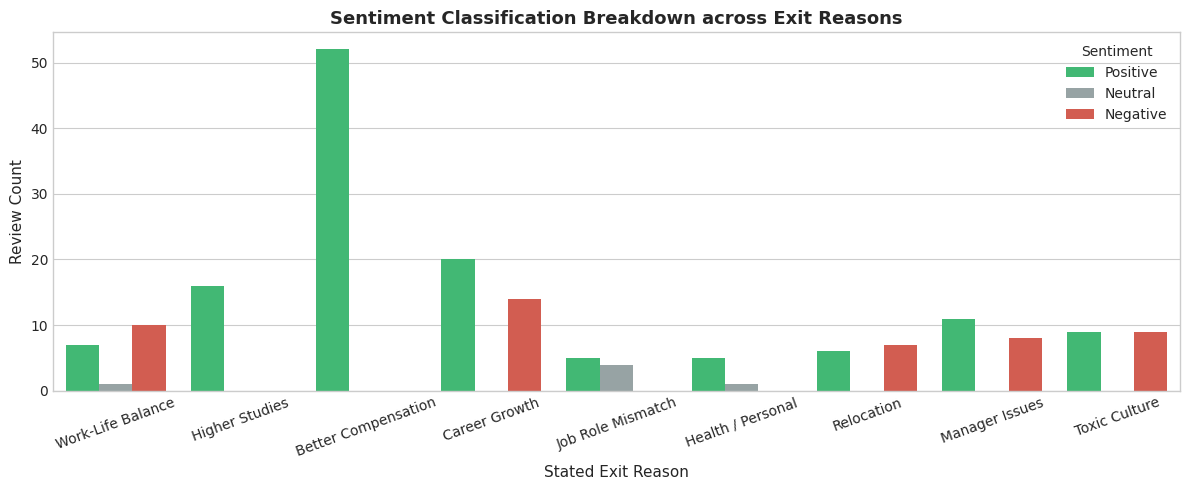

In [9]:
# 2.3 Mixed-Sentiment Analysis & Driver Extraction
# Identify mixed sentiment: Positive culture/team rating (>=4) but low compensation rating (<=2) or negative sentiment
mixed_reviews = reviews_df[
    (reviews_df['rating_culture'] >= 4) & (reviews_df['rating_compensation'] <= 2)
]

print(f"⚠️ Detected {len(mixed_reviews)} Mixed-Sentiment Reviews (High Culture Rating + Low Compensation Rating)")
print("\nSample Mixed Reviews:")
for idx, row in mixed_reviews[['employee_id', 'stated_reason', 'review_text', 'rating_culture', 'rating_compensation']].head(3).iterrows():
    print(f"• Employee {row['employee_id']} ({row['stated_reason']}): Culture Rating={row['rating_culture']}, Comp Rating={row['rating_compensation']}")
    print(f"  Review: \"{row['review_text']}\"\n")

# Distribution of sentiment categories across exit reasons
fig, ax = plt.subplots(figsize=(12, 5))
sns.countplot(data=reviews_df, x='stated_reason', hue='sentiment_category', palette={'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}, ax=ax)
ax.set_title('Sentiment Classification Breakdown across Exit Reasons')
ax.set_xlabel('Stated Exit Reason')
ax.set_ylabel('Review Count')
plt.xticks(rotation=20)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


---
## 🎯 Section 3: Recruitment & Workforce Efficiency

In this section, we analyze hiring funnel metrics, cost-per-hire, recruitment source effectiveness against early attrition, headcount vs. target gaps, span of control, and gender pay parity.


             RECRUITMENT METRICS                  
Average Time-to-Hire  : 53.8 days
Average Offer-to-Join : 37.1 days
Average Cost-per-Hire : ₹36,393 INR


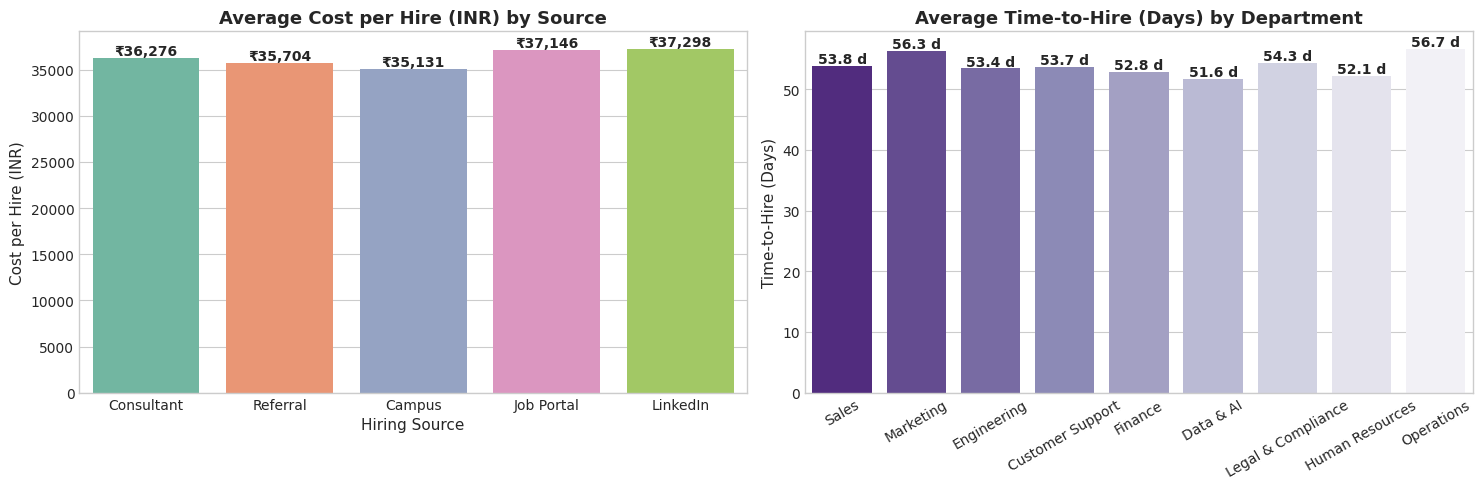

In [10]:
# 3.1 Recruitment Funnel & Cost Metrics
recruitment_df['req_open_date'] = pd.to_datetime(recruitment_df['req_open_date'])
recruitment_df['offer_date'] = pd.to_datetime(recruitment_df['offer_date'])
recruitment_df['join_date'] = pd.to_datetime(recruitment_df['join_date'])

recruitment_df['time_to_hire_days'] = (recruitment_df['join_date'] - recruitment_df['req_open_date']).dt.days
recruitment_df['offer_to_join_days'] = (recruitment_df['join_date'] - recruitment_df['offer_date']).dt.days

print("==================================================")
print("             RECRUITMENT METRICS                  ")
print("==================================================")
print(f"Average Time-to-Hire  : {recruitment_df['time_to_hire_days'].mean():.1f} days")
print(f"Average Offer-to-Join : {recruitment_df['offer_to_join_days'].mean():.1f} days")
print(f"Average Cost-per-Hire : ₹{recruitment_df['cost_per_hire_inr'].mean():,.0f} INR")
print("==================================================")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cost per Hire by Source
sns.barplot(data=recruitment_df, x='source', y='cost_per_hire_inr', ax=axes[0], estimator=np.mean, errorbar=None, palette='Set2')
axes[0].set_title('Average Cost per Hire (INR) by Source')
axes[0].set_ylabel('Cost per Hire (INR)')
axes[0].set_xlabel('Hiring Source')
for p in axes[0].patches:
    axes[0].annotate(f'₹{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# Time-to-Hire by Department
sns.barplot(data=recruitment_df, x='department', y='time_to_hire_days', ax=axes[1], estimator=np.mean, errorbar=None, palette='Purples_r')
axes[1].set_title('Average Time-to-Hire (Days) by Department')
axes[1].set_ylabel('Time-to-Hire (Days)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f} d', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()


📌 Sourcing Source Effectiveness & Early Attrition Risk:
       source  total_hires  early_exits_12m  early_attrition_pct  avg_cost_inr
0      Campus          235               25            10.638298  35130.612766
1  Consultant          142               10             7.042254  36275.584507
2  Job Portal          430               34             7.906977  37145.986047
3    LinkedIn          293               15             5.119454  37297.552901
4    Referral          400               35             8.750000  35703.517500


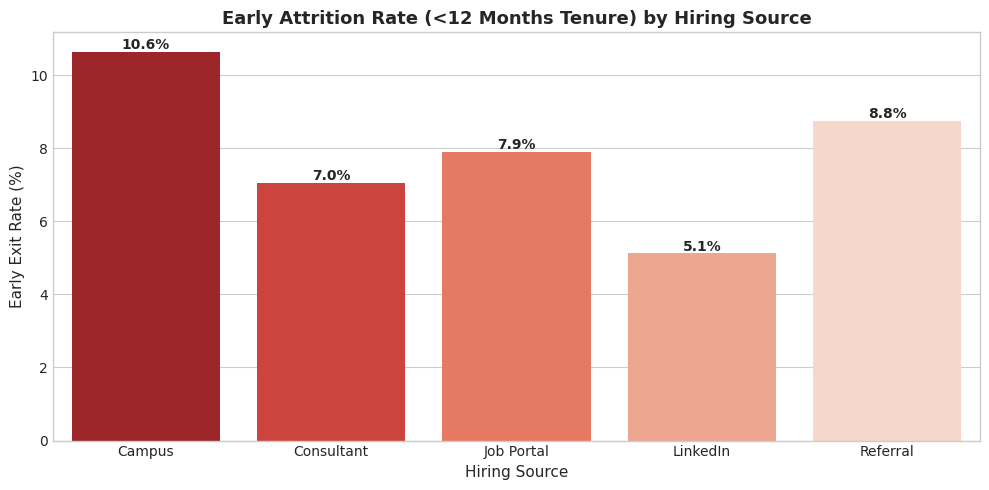

In [11]:
# 3.2 Recruitment Source Quality vs. Early Attrition
rec_master = recruitment_df.merge(attrition_df, left_on='hired_employee_id', right_on='employee_id', how='left')
rec_master['is_early_exit_12m'] = (rec_master['tenure_months'] < 12).fillna(False)

source_eval = rec_master.groupby('source').agg(
    total_hires=('hired_employee_id', 'count'),
    early_exits_12m=('is_early_exit_12m', 'sum'),
    avg_cost_inr=('cost_per_hire_inr', 'mean')
).reset_index()

source_eval['early_attrition_pct'] = (source_eval['early_exits_12m'] / source_eval['total_hires']) * 100

print("📌 Sourcing Source Effectiveness & Early Attrition Risk:")
print(source_eval[['source', 'total_hires', 'early_exits_12m', 'early_attrition_pct', 'avg_cost_inr']])

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=source_eval, x='source', y='early_attrition_pct', palette='Reds_r', ax=ax)
ax.set_title('Early Attrition Rate (<12 Months Tenure) by Hiring Source')
ax.set_ylabel('Early Exit Rate (%)')
ax.set_xlabel('Hiring Source')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()


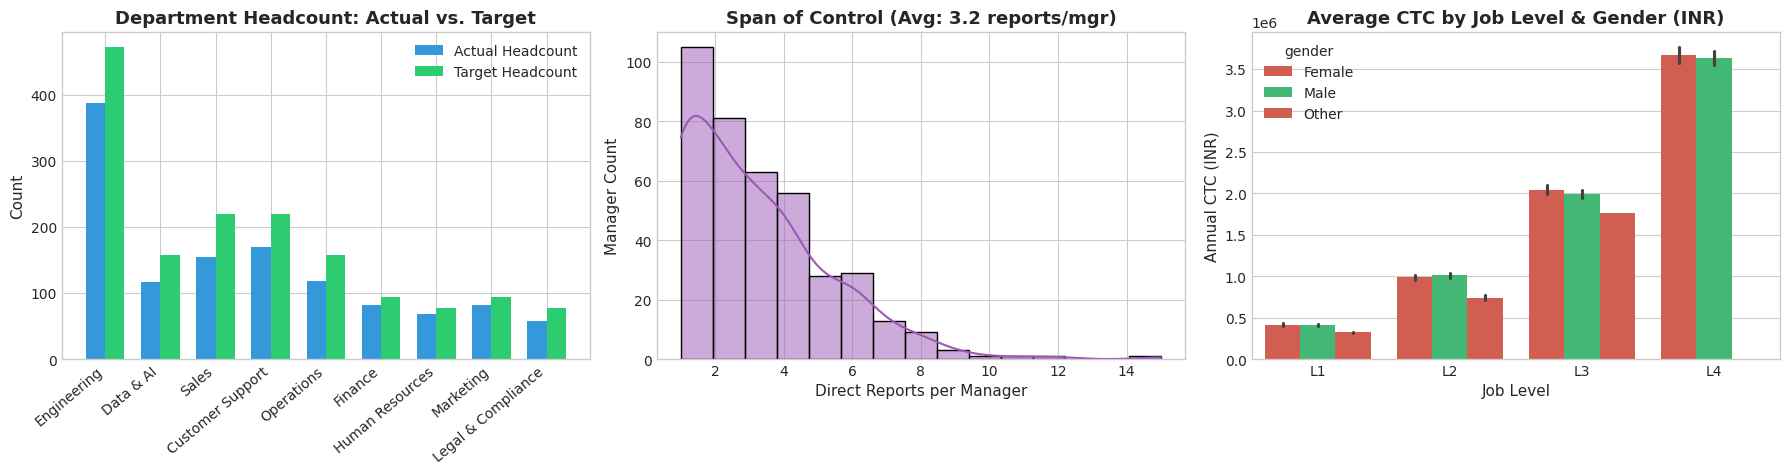


💰 Gender Pay Gap Percentage by Job Level ((Male - Female) / Male %):
gender             Male        Female  pay_gap_pct
job_level                                         
L1         4.111638e+05  4.175926e+05    -1.563562
L2         1.011596e+06  9.884786e+05     2.285223
L3         1.995817e+06  2.044008e+06    -2.414590
L4         3.634693e+06  3.671485e+06    -1.012268


In [12]:
# 3.3 Headcount vs Target, Span of Control & Gender Pay Gap

# Headcount vs Target Gap
dept_hc = employees_df[employees_df['employment_status'] == 'Active'].groupby('dept_id').size().reset_index(name='actual_headcount')
dept_summary = departments_df.merge(dept_hc, on='dept_id', how='left')
dept_summary['headcount_gap'] = dept_summary['head_count_target'] - dept_summary['actual_headcount']

# Span of Control (Direct reports per manager)
span_of_control = employees_df[employees_df['employment_status'] == 'Active'].groupby('manager_id').size()

# Gender Pay Gap
pay_gap = employees_df.groupby(['job_level', 'gender'])['annual_ctc_inr'].mean().unstack()
pay_gap['pay_gap_pct'] = ((pay_gap['Male'] - pay_gap['Female']) / pay_gap['Male']) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Headcount vs Target
x = np.arange(len(dept_summary))
width = 0.35
axes[0].bar(x - width/2, dept_summary['actual_headcount'], width, label='Actual Headcount', color='#3498db')
axes[0].bar(x + width/2, dept_summary['head_count_target'], width, label='Target Headcount', color='#2ecc71')
axes[0].set_xticks(x)
axes[0].set_xticklabels(dept_summary['dept_name'], rotation=40, ha='right')
axes[0].set_title('Department Headcount: Actual vs. Target')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: Span of Control
sns.histplot(span_of_control, bins=15, kde=True, ax=axes[1], color='#9b59b6')
axes[1].set_title(f'Span of Control (Avg: {span_of_control.mean():.1f} reports/mgr)')
axes[1].set_xlabel('Direct Reports per Manager')
axes[1].set_ylabel('Manager Count')

# Plot 3: Gender Pay Gap
sns.barplot(data=employees_df, x='job_level', y='annual_ctc_inr', hue='gender', ax=axes[2], palette=['#e74c3c', '#2ecc71'])
axes[2].set_title('Average CTC by Job Level & Gender (INR)')
axes[2].set_ylabel('Annual CTC (INR)')
axes[2].set_xlabel('Job Level')

plt.tight_layout()
plt.show()

print("\n💰 Gender Pay Gap Percentage by Job Level ((Male - Female) / Male %):")
print(pay_gap[['Male', 'Female', 'pay_gap_pct']])


---
## 🛡️ Section 4: HR Compliance, Legal & Risk Auditing

In this section, we audit mandatory compliance training completion rates, background verification clearance, NDA signing rates, and track grievances, POSH complaints, and disciplinary records across departments.


📋 Compliance Training Overview:
             training_name  total_assigned  completed  overdue  \
0             Anti-Bribery            1237        909      134   
1          Code of Conduct            1237        928      114   
2  Data Privacy & DPDP Act            1237        936      129   
3            Fire & Safety            1237        949      108   
4     Information Security            1237        922      124   
5           POSH Awareness            1237        941      122   

   completion_pct  avg_score  
0       73.484236  79.574257  
1       75.020210  79.532328  
2       75.666936  79.646368  
3       76.717866  80.134879  
4       74.535166  79.229935  
5       76.071140  79.598300  


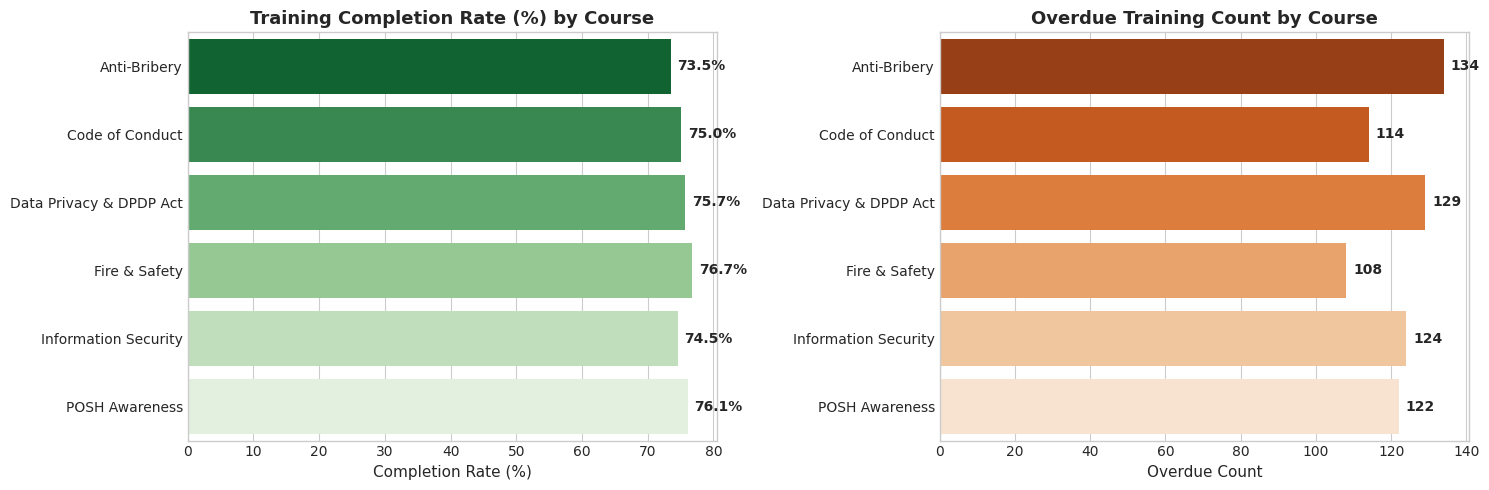

In [13]:
# 4.1 Mandatory Compliance Training Completion Audit
trng_summary = compliance_trng_df.groupby('training_name').agg(
    total_assigned=('employee_id', 'count'),
    completed=('status', lambda x: (x == 'Completed').sum()),
    overdue=('status', lambda x: (x == 'Overdue').sum()),
    avg_score=('score_pct', 'mean')
).reset_index()

trng_summary['completion_pct'] = (trng_summary['completed'] / trng_summary['total_assigned']) * 100

print("📋 Compliance Training Overview:")
print(trng_summary[['training_name', 'total_assigned', 'completed', 'overdue', 'completion_pct', 'avg_score']])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Completion Percentage by Course
sns.barplot(data=trng_summary, y='training_name', x='completion_pct', ax=axes[0], palette='Greens_r')
axes[0].set_title('Training Completion Rate (%) by Course')
axes[0].set_xlabel('Completion Rate (%)')
axes[0].set_ylabel('')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')

# Overdue Count by Course
sns.barplot(data=trng_summary, y='training_name', x='overdue', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Overdue Training Count by Course')
axes[1].set_xlabel('Overdue Count')
axes[1].set_ylabel('')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()


          LEGAL & RECORDS COMPLIANCE              
Background Verification (BGV) Status:
  • Cleared: 1356 (90.4%)
  • Pending: 103 (6.9%)
  • Discrepancy: 41 (2.7%)
PF / UAN Linkage Rate   : 94.7%
NDA Signed Rate         : 96.2%
Policy Acknowledged Rate: 91.6%


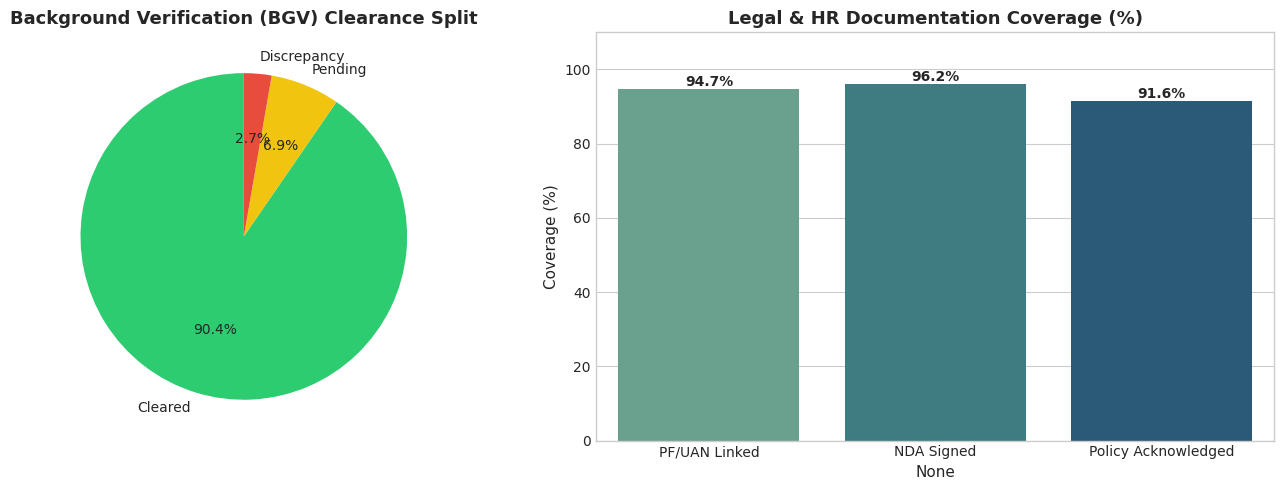

In [14]:
# 4.2 Background Verification (BGV) & Employee Legal Records Audit
bgv_counts = compliance_rec_df['background_verification'].value_counts()
pf_linked_pct = (compliance_rec_df['pf_uan_linked'] == 'Yes').mean() * 100
nda_signed_pct = (compliance_rec_df['nda_signed'] == 'Yes').mean() * 100
policy_ack_pct = (compliance_rec_df['policy_acknowledged'] == 'Yes').mean() * 100

print("==================================================")
print("          LEGAL & RECORDS COMPLIANCE              ")
print("==================================================")
print(f"Background Verification (BGV) Status:")
for status, count in bgv_counts.items():
    print(f"  • {status}: {count} ({count/len(compliance_rec_df)*100:.1f}%)")
print(f"PF / UAN Linkage Rate   : {pf_linked_pct:.1f}%")
print(f"NDA Signed Rate         : {nda_signed_pct:.1f}%")
print(f"Policy Acknowledged Rate: {policy_ack_pct:.1f}%")
print("==================================================")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BGV Distribution Pie Chart
axes[0].pie(bgv_counts, labels=bgv_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#f1c40f', '#e74c3c'], startangle=90)
axes[0].set_title('Background Verification (BGV) Clearance Split')

# Compliance Metrics Bar Chart
comp_metrics = pd.Series({
    'PF/UAN Linked': pf_linked_pct,
    'NDA Signed': nda_signed_pct,
    'Policy Acknowledged': policy_ack_pct
})
sns.barplot(x=comp_metrics.index, y=comp_metrics.values, ax=axes[1], palette='crest')
axes[1].set_title('Legal & HR Documentation Coverage (%)')
axes[1].set_ylabel('Coverage (%)')
axes[1].set_ylim(0, 110)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()


🚨 Compliance Risk Hotspots by Department:
           department  total_grievances  total_posh  total_disciplinary
0    Customer Support                33           4                   5
1           Data & AI                17           1                   5
2         Engineering                68           5                  24
3             Finance                15           0                   8
4     Human Resources                12           2                   3
5  Legal & Compliance                 8           0                   3
6           Marketing                21           0                   6
7          Operations                21           2                  10
8               Sales                25           4                   8


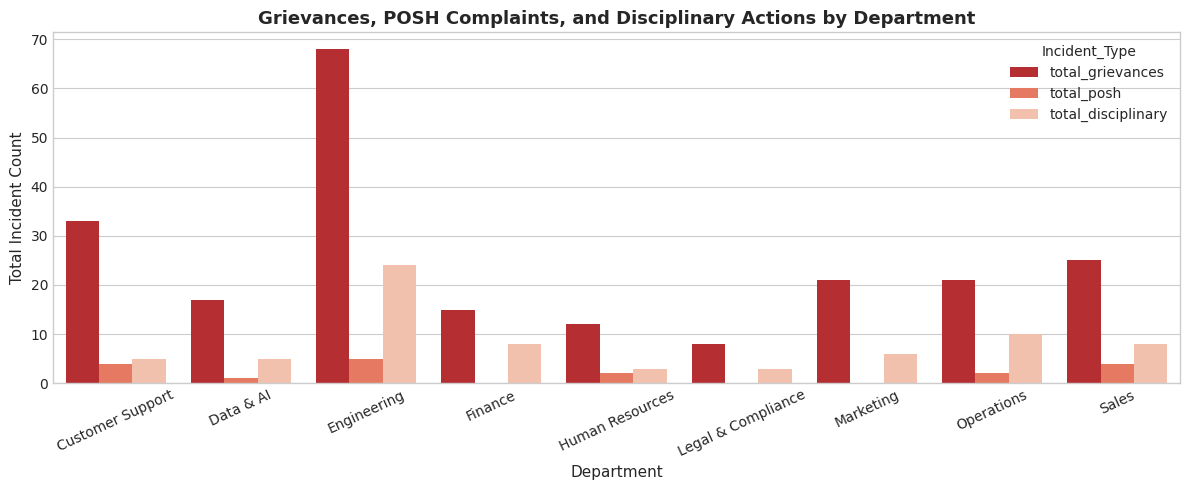

In [15]:
# 4.3 Grievances, POSH Complaints & Disciplinary Action Hotspots
master_compliance = master_df[['employee_id', 'department', 'job_level', 'grievances_raised', 'posh_complaints', 'disciplinary_actions']].copy()

dept_risk = master_compliance.groupby('department').agg(
    total_grievances=('grievances_raised', 'sum'),
    total_posh=('posh_complaints', 'sum'),
    total_disciplinary=('disciplinary_actions', 'sum')
).reset_index()

print("🚨 Compliance Risk Hotspots by Department:")
print(dept_risk)

fig, ax = plt.subplots(figsize=(12, 5))
dept_risk_melted = dept_risk.melt(id_vars='department', var_name='Incident_Type', value_name='Count')
sns.barplot(data=dept_risk_melted, x='department', y='Count', hue='Incident_Type', palette='Reds_r', ax=ax)
ax.set_title('Grievances, POSH Complaints, and Disciplinary Actions by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Total Incident Count')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


---
## 💡 Section 5: Strategic HR Recommendations & Action Plan

Based on our multi-dimensional quantitative and NLP findings across all 10 datasets, we propose the following targeted interventions:

1. **Targeted Retention in High-Risk Verticals**:
   - **Sales & Customer Support** and **Level 1 (Junior)** roles exhibit the highest attrition. Implement workload caps for overtime hours and introduce flexible/hybrid options for employees commuting >30 km.
   - Deploy early-warning alerts for employees exhibiting spikes in **unplanned absences** (>3/month) or **late logins**.

2. **Compensation & Review Alignment**:
   - Mixed-sentiment exit analysis reveals strong cultural appreciation paired with dissatisfaction in salary progression. Review pay equity and competitive benchmark compensation for high performers.

3. **Recruitment Channel Optimization**:
   - Sourcing via **Consultants** drives up Cost-per-Hire and correlates with higher 12-month early attrition. Shift budget allocations toward high-retention channels such as **Employee Referrals** and direct hiring.

4. **Compliance Enforcement & BGV Verification**:
   - Accelerate BGV verification for pending cases and enforce automated reminders for overdue **POSH** and **Code of Conduct** compliance training modules.

---
